<a href="https://colab.research.google.com/github/adi-halder/python-ai-learning/blob/main/day4_stock_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Python Day 4 - Stock Market AI Predictor
# BTech AI/ML | Vacation Learning

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [4]:
# Load real Apple stock data 2021-2026
url = "https://query1.finance.yahoo.com/v7/finance/download/AAPL?period1=1609459200&period2=1746057600&interval=1d"
df =  pd.read_csv(url)
print(df.head())

HTTPError: HTTP Error 429: Too Many Requests

In [5]:
# Install yfinance
!pip install yfinance --quiet

import yfinance as yf

# Download Apple stock data 2021-2026
df = yf.download("AAPL", start = "2021-01-01", end = "2026-01-01")
print(df.head())
print(df.shape)

/tmp/ipykernel_2096/113662173.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start = "2021-01-01", end = "2026-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2021-01-04  125.856689  129.941364  123.279451  129.853838  143301900
2021-01-05  127.412743  128.122709  124.903582  125.350958   97664900
2021-01-06  123.123856  127.451673  122.909895  124.213106  155088000
2021-01-07  127.325233  128.015745  124.349256  124.835528  109578200
2021-01-08  128.424240  128.988317  126.654206  128.793796  105158200
(1255, 5)


In [6]:
# Step 1 - Flatten column names
df.columns = ["Close", "High", "Low", "Open", "Volume"]

# Step 2 - Create target (did price go UP or DOWN next day?)
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

# Step 3 - Create features
df["Daily_Return"] = (df["Close"] - df["Open"]) / df["Open"] * 100
df["Price_Range"] = df["High"] - df["Low"]

# Step 4 - Remove missing rows
df = df.dropna()
print(df[["Close", "Target", "Daily_Return", "Price_Range"]].head(10))

                 Close  Target  Daily_Return  Price_Range
Date                                                     
2021-01-04  125.856689       1     -3.078191     6.661913
2021-01-05  127.412743       0      1.644810     3.219127
2021-01-06  123.123856       1     -0.876920     4.541778
2021-01-07  127.325233       1      1.994389     3.666489
2021-01-08  128.424240       0     -0.286936     2.334111
2021-01-11  125.438492       0     -0.162556     1.624144
2021-01-12  125.263443       1      0.233465     2.752296
2021-01-13  127.296089       0      1.654244     2.878718
2021-01-14  125.370468       0     -1.444954     2.178501
2021-01-15  123.649040       1     -1.273489     3.131588


In [8]:
# Step 5 - Define features and target
features = ["Open", "High", "Low", "Close", "Volume", "Daily_Return", "Price_Range"]
X = df[features]      # input data (what AI learns from)
Y = df["Target"]      # output data (what AI predicts)

# Step 6 - Split data into training and testing
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

# Step 7 - Train the AI model!
model = DecisionTreeClassifier()
model.fit(X_train, Y_train)

# Step 8 - Test accuracy
predictions = model.predict(X_test)
accuracy = accuracy_score(Y_test, predictions)
print("Model Accuracy:", round(accuracy * 100, 2), "%")


Training rows: 1004
Testing rows: 251
Model Accuracy: 52.19 %


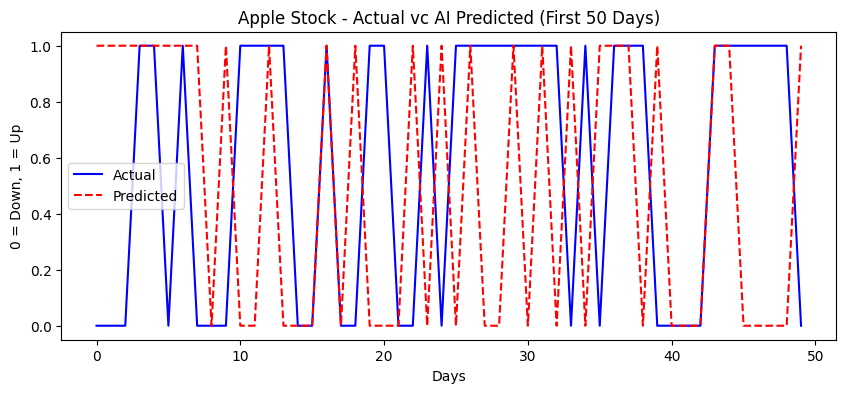

In [9]:
# Step 9 - Visualize actual vs predicted
plt.figure(figsize=(10, 4))
plt.plot(Y_test.values[:50], label="Actual", color="blue")
plt.plot(predictions[:50], label="Predicted", color="red", linestyle="dashed")
plt.title("Apple Stock - Actual vc AI Predicted (First 50 Days)")
plt.xlabel("Days")
plt.ylabel("0 = Down, 1 = Up")
plt.legend()
plt.show()